In [1]:
!pip install umap-learn scikit-learn plotly openpyxl tensorflow gymnasium

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import umap.umap_ as umap
import plotly.express as px

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import gymnasium as gym

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])
df.head()

Saving stock_umap_dataset.xlsx to stock_umap_dataset.xlsx


,date,close,volume,open,high,low,return,ma_5,ma_10,volatility_5,momentum
0,2024-01-01,100.496714,6401,100.496714,101.011962,99.827112,0.000000,101.337097,102.521264,0.000000,100.496714
1,2024-01-02,100.358450,2761,100.496714,100.987900,100.288518,-0.001376,101.337097,102.521264,0.000000,100.358450
2,2024-01-03,101.006138,1876,100.358450,102.002474,99.718282,0.006454,101.337097,102.521264,0.000000,101.006138
3,2024-01-04,102.529168,4812,101.006138,103.426604,100.734991,0.015079,101.337097,102.521264,0.000000,102.529168
4,2024-01-05,102.295015,2460,102.529168,102.992549,101.702203,-0.002284,101.337097,102.521264,0.007284,102.295015


In [4]:
#feature engeenering
features = [
    "close", "volume", "open", "high", "low",
    "return", "ma_5", "ma_10",
    "volatility_5", "momentum"
]

df = df.dropna()
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

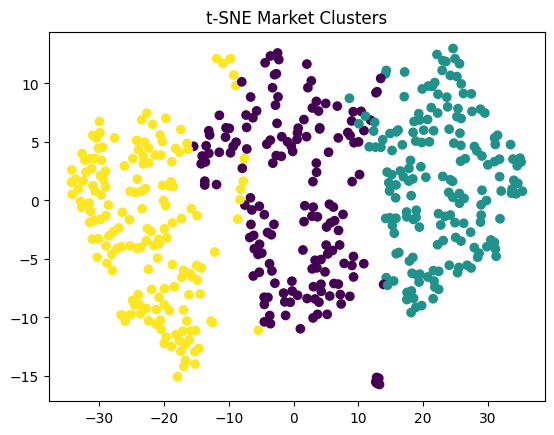

In [6]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)

df["tsne1"] = tsne_result[:,0]
df["tsne2"] = tsne_result[:,1]

plt.scatter(df["tsne1"], df["tsne2"], c=df["cluster"])
plt.title("t-SNE Market Clusters")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


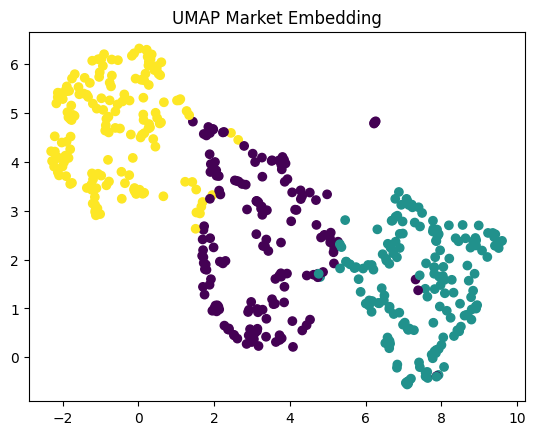

In [7]:
#Umap visualization
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(X_scaled)

df["umap1"] = umap_result[:,0]
df["umap2"] = umap_result[:,1]

plt.scatter(df["umap1"], df["umap2"], c=df["cluster"])
plt.title("UMAP Market Embedding")
plt.show()

In [8]:
fig = px.scatter(
    df,
    x="umap1",
    y="umap2",
    color=df["cluster"].astype(str),
    hover_data=["close", "volume", "return"]
)

fig.show()

In [9]:
data = df["close"].values.reshape(-1,1)

scaler_price = StandardScaler()
data_scaled = scaler_price.fit_transform(data)

X_lstm = []
y_lstm = []

for i in range(10, len(data_scaled)):
    X_lstm.append(data_scaled[i-10:i])
    y_lstm.append(data_scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

In [10]:
#LSTM model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(10,1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")
model.fit(X_lstm, y_lstm, epochs=5, batch_size=16)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.2285
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0798
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0812
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0717
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0650


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


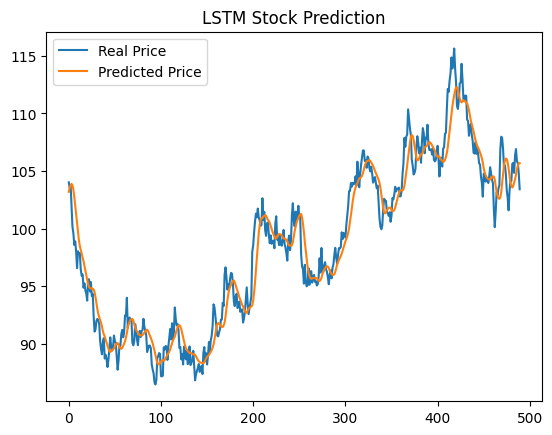

In [11]:
pred = model.predict(X_lstm)

pred_actual = scaler_price.inverse_transform(pred)
real_actual = scaler_price.inverse_transform(y_lstm)

plt.plot(real_actual, label="Real Price")
plt.plot(pred_actual, label="Predicted Price")
plt.legend()
plt.title("LSTM Stock Prediction")
plt.show()

In [13]:
#tranding signal
df["signal"] = np.where(df["return"] > 0.002, "BUY",
                 np.where(df["return"] < -0.002, "SELL", "HOLD"))

df["signal"].value_counts()

,count
signal,
SELL,213
BUY,212
HOLD,75


In [15]:
#DQN trading agent
class TradingEnv:
    def __init__(self, data):
        self.data = data
        self.current = 10
        self.balance = 10000
        self.shares = 0

    def step(self, action):
        price = self.data[self.current]

        if action == 0:  # buy
            self.shares += 1
            self.balance -= price

        elif action == 1:  # sell
            self.shares -= 1
            self.balance += price

        reward = self.balance + self.shares * price
        self.current += 1

        done = self.current >= len(self.data)-1
        return reward, done

In [16]:
model = Sequential([
    Dense(64, input_dim=10, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='linear')  # buy, sell, hold
])

model.compile(optimizer="adam", loss="mse")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [17]:
print("Market clusters:")
print(df["cluster"].value_counts())

print("\nSignals:")
print(df["signal"].value_counts())

Market clusters:
cluster
1    172
2    166
0    162
Name: count, dtype: int64

Signals:
signal
SELL    213
BUY     212
HOLD     75
Name: count, dtype: int64
